In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
train_df = pd.read_csv("../input/new-york-city-taxi-fare-prediction/train.csv",nrows = 1000000)
test_df = pd.read_csv("../input/new-york-city-taxi-fare-prediction/test.csv")


In [3]:
train_df.isnull().sum()


key                   0
fare_amount           0
pickup_datetime       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude    10
dropoff_latitude     10
passenger_count       0
dtype: int64

In [4]:
# drop NaN rows in dropoff_longitude and dropoff_latitude
train_df.dropna(axis=0, subset=['dropoff_longitude', 'dropoff_latitude'], inplace=True)
train_df = train_df.reset_index(drop=True)


In [5]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)
train_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,999990.00000,999990.00000,999990.00000,999990.00000,999990.00000,999990.00000
mean,11.34795,-72.52670,39.92904,-72.52786,39.91995,1.68494
std,9.82179,12.05778,7.62609,11.32449,8.20142,1.32391
min,-44.90000,-3377.68093,-3116.28538,-3383.29661,-3114.33857,0.00000
25%,6.00000,-73.99206,40.73497,-73.99138,40.73405,1.00000
50%,8.50000,-73.98179,40.75270,-73.98014,40.75317,1.00000
75%,12.50000,-73.96709,40.76715,-73.96365,40.76813,2.00000
max,500.00000,2522.27133,2621.62843,45.58162,1651.55343,208.00000


In [6]:
print('Number of observations out of valid range in coordinate columns:', end="\n")

print('pickup_longitude', end=': ')
print((train_df.pickup_longitude <-180).sum()+(train_df.pickup_longitude > 180).sum())

print('pickup_latitude', end=': ')
print((train_df.pickup_latitude <-90).sum()+(train_df.pickup_latitude > 90).sum())

print('dropoff_longitude', end=': ')
print((train_df.dropoff_longitude <-180).sum()+(train_df.dropoff_longitude > 180).sum())

print('dropoff_latitude', end=': ')
print((train_df.dropoff_latitude <-90).sum()+(train_df.dropoff_latitude > 90).sum())


Number of observations out of valid range in coordinate columns:
pickup_longitude: 15
pickup_latitude: 12
dropoff_longitude: 13
dropoff_latitude: 12


In [7]:
# Drop these values
train_df = train_df.drop(train_df[(train_df.pickup_longitude < -180) | (train_df.pickup_longitude > 180)].index, axis=0)
train_df = train_df.drop(train_df[(train_df.pickup_latitude < -90) | (train_df.pickup_latitude > 90)].index, axis=0)
train_df = train_df.drop(train_df[(train_df.dropoff_longitude < -180) | (train_df.dropoff_longitude > 180)].index, axis=0)
train_df = train_df.drop(train_df[(train_df.dropoff_latitude < -90) | (train_df.dropoff_latitude > 90)].index, axis=0)


In [8]:
train_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,999950.00000,999950.00000,999950.00000,999950.00000,999950.00000,999950.00000
mean,11.34793,-72.51730,39.92674,-72.51522,39.92587,1.68494
std,9.82178,10.39359,6.08938,10.39737,6.09375,1.32390
min,-44.90000,-128.17595,-74.01659,-121.39125,-74.03520,0.00000
25%,6.00000,-73.99206,40.73497,-73.99138,40.73405,1.00000
50%,8.50000,-73.98179,40.75270,-73.98014,40.75317,1.00000
75%,12.50000,-73.96709,40.76715,-73.96365,40.76813,2.00000
max,500.00000,40.85036,69.40000,45.58162,81.51018,208.00000


In [9]:
train_df[(train_df.pickup_longitude>=40)]


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2147,2013-05-24 14:54:00.00000079,5.00000,2013-05-24 14:54:00 UTC,40.75158,-73.98697,40.75887,-73.97835,2
3827,2013-06-20 04:28:00.0000001,11.00000,2013-06-20 04:28:00 UTC,40.71983,-73.98847,40.72331,-73.93943,1
4783,2013-05-22 06:28:00.0000004,6.50000,2013-05-22 06:28:00 UTC,40.74826,-73.99184,40.74037,-73.97901,1
6705,2013-05-22 15:33:00.000000175,13.00000,2013-05-22 15:33:00 UTC,40.76613,-73.98328,40.75742,-73.97796,2
7525,2013-05-22 10:54:00.000000140,13.00000,2013-05-22 10:54:00 UTC,40.76049,-73.97305,40.74037,-73.99439,1
...,...,...,...,...,...,...,...,...
986498,2013-05-23 07:03:00.00000057,5.50000,2013-05-23 07:03:00 UTC,40.78782,-73.95559,40.77812,-73.95636,2
988616,2013-05-23 23:32:00.000000174,12.50000,2013-05-23 23:32:00 UTC,40.76323,-73.97772,40.72946,-74.00512,2
997488,2013-05-17 02:01:00.00000028,9.00000,2013-05-17 02:01:00 UTC,40.72564,-73.97777,40.71868,-73.99273,1
997499,2013-05-22 01:13:00.00000047,9.00000,2013-05-22 01:13:00 UTC,40.73256,-73.99929,40.70996,-74.01574,2


In [10]:
# Now let's switch these rows back

indx = train_df[(train_df.pickup_longitude>=40)].index
train_df.loc[indx,['dropoff_longitude','dropoff_latitude']] = train_df.loc[indx,['dropoff_latitude','dropoff_longitude']].values
train_df.loc[indx,['pickup_longitude','pickup_latitude']] = train_df.loc[indx,['pickup_latitude','pickup_longitude']].values


In [11]:
# Also, Let's filter and remove values that are outside these latitude and longitude ranges of NYC

# -75 <= pickup_longitude <= -72 
# -75 <= dropoff_longitude <= -72
# 40 <= pickup_latitude <= 42
# 40 <= dropoff_latitude <= 42

train_df = train_df.drop(train_df[(train_df.pickup_longitude<-75) | (train_df.pickup_longitude>-72)].index, axis=0)
train_df = train_df.drop(train_df[(train_df.dropoff_longitude<-75) | (train_df.dropoff_longitude>-72)].index, axis=0)
train_df = train_df.drop(train_df[(train_df.pickup_latitude<40) | (train_df.pickup_latitude>42)].index, axis=0)
train_df = train_df.drop(train_df[(train_df.dropoff_latitude<40) | (train_df.dropoff_latitude>42)].index, axis=0)


In [12]:
train_df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,979709.00000,979709.00000,979709.00000,979709.00000,979709.00000,979709.00000
mean,11.33187,-73.97514,40.75107,-73.97425,40.75140,1.68522
std,9.74750,0.03912,0.03004,0.03835,0.03319,1.30796
min,-44.90000,-74.96814,40.05272,-74.96426,40.04118,0.00000
25%,6.00000,-73.99227,40.73657,-73.99157,40.73558,1.00000
50%,8.50000,-73.98208,40.75341,-73.98059,40.75387,1.00000
75%,12.50000,-73.96831,40.76758,-73.96532,40.76842,2.00000
max,500.00000,-72.70287,41.80025,-72.19609,41.92382,6.00000


In [13]:
train_df.passenger_count.value_counts()


passenger_count
1    677025
2    145340
5     69159
3     42891
4     21012
6     20800
0      3482
Name: count, dtype: int64

In [14]:
train_df = train_df.drop(train_df[train_df.passenger_count == 0].index, axis=0)


In [15]:
train_df.fare_amount.sort_values(ascending=False)


101885   500.00000
247669   495.00000
287636   450.00000
329008   450.00000
233873   450.00000
            ...   
323635    -6.50000
857712    -6.50000
427599   -18.10000
534745   -29.87000
58937    -44.90000
Name: fare_amount, Length: 976227, dtype: float64

In [16]:
train_df = train_df.drop(train_df[train_df.fare_amount <= 0].index, axis=0)
train_df['fare_amount'].sort_values(ascending=False)


101885   500.00000
247669   495.00000
233873   450.00000
329008   450.00000
287636   450.00000
            ...   
843937     0.01000
217966     0.01000
90010      0.01000
671865     0.01000
194168     0.01000
Name: fare_amount, Length: 976169, dtype: float64

In [17]:
test_df.isna().sum()


key                  0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [18]:
test_df.describe()


,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,9914.00000,9914.00000,9914.00000,9914.00000,9914.00000
mean,-72.36544,39.85407,-72.35530,39.84990,1.70173
std,10.90123,6.32535,10.92825,6.33854,1.32833
min,-74.17807,-74.00043,-75.43773,-74.00951,0.00000
25%,-73.99227,40.73469,-73.99136,40.73366,1.00000
50%,-73.98198,40.75250,-73.98022,40.75321,1.00000
75%,-73.96672,40.76711,-73.96360,40.76814,2.00000
max,40.79030,41.36614,40.80071,41.05638,6.00000


In [19]:
# Check the data types of columns
train_df.dtypes


key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [20]:
# Convert to date type
# training data
train_df['pickup_datetime'] = pd.to_datetime(train_df['pickup_datetime'])

# test data
test_df['pickup_datetime'] = pd.to_datetime(test_df['pickup_datetime'])


In [21]:
def date_splitter(df):
    df['Year'] = df['pickup_datetime'].dt.year
    df['Month'] = df['pickup_datetime'].dt.month
    df['Day'] = df['pickup_datetime'].dt.day
    df['Weekday'] = df['pickup_datetime'].dt.dayofweek
    df['Hour'] = df['pickup_datetime'].dt.hour
    

# extract information from pickup_datetime
date_splitter(train_df)
date_splitter(test_df)

# drop unnecessary pickup_datetime column
train_df.drop(['pickup_datetime'], axis=1, inplace=True)
test_df.drop(['pickup_datetime'], axis=1, inplace=True)


In [22]:
import math

def haversine_distance(df):
    coord = ['pickup_latitude', 
             'pickup_longitude', 
             'dropoff_latitude', 
             'dropoff_longitude']
    
    phi1, lambda1, phi2, lambda2 = [df[i]*math.pi/180.0 for i in coord]
    
    R = 6371
    
    # distance between latitudes and longitudes
    dPhi = (phi2 - phi1)
    dLambda = (lambda2 - lambda1)
    
    a = np.sin(dPhi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dLambda / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    d = (R * c)
    
    df['Distance'] = d
    
    
haversine_distance(train_df)
haversine_distance(test_df)


In [23]:
train_df.Distance.sort_values()


326345     0.00000
406950     0.00000
81011      0.00000
626595     0.00000
209295     0.00000
            ...   
724757   104.25497
538455   107.13584
222207   110.83308
606417   116.13505
247669   140.51498
Name: Distance, Length: 976169, dtype: float64

In [24]:
train_df = train_df.drop(train_df[train_df.Distance<0.5].index, axis=0)


<Axes: xlabel='passenger_count', ylabel='fare_amount'>

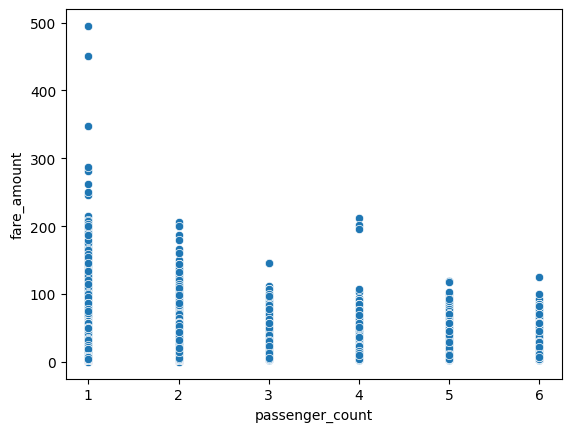

In [25]:
sns.scatterplot(x='passenger_count', y='fare_amount', data=train_df)


<Axes: xlabel='Year', ylabel='fare_amount'>

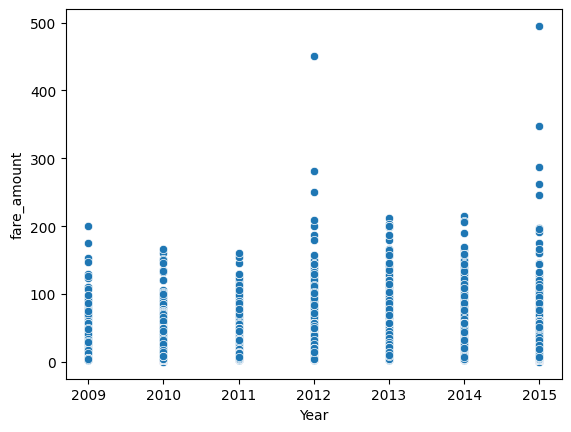

In [26]:
sns.scatterplot(x='Year', y='fare_amount', data=train_df)


<Axes: xlabel='Month', ylabel='fare_amount'>

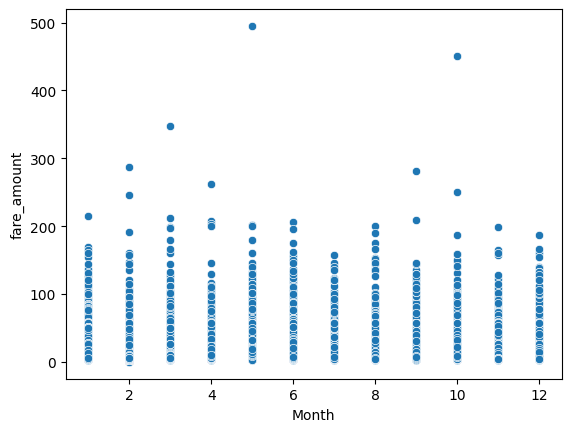

In [27]:
sns.scatterplot(x='Month', y='fare_amount', data=train_df)


<Axes: xlabel='Day', ylabel='fare_amount'>

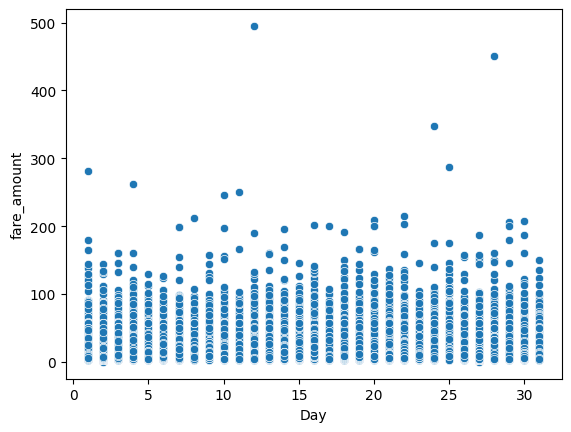

In [28]:
sns.scatterplot(x='Day', y='fare_amount', data=train_df)


<Axes: xlabel='Weekday', ylabel='fare_amount'>

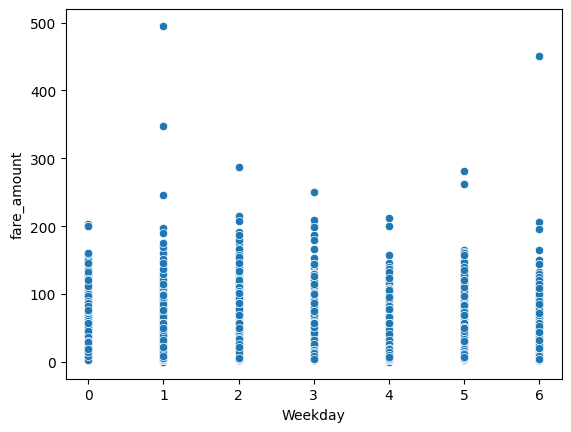

In [29]:
sns.scatterplot(x='Weekday', y='fare_amount', data=train_df)


<Axes: xlabel='Hour', ylabel='fare_amount'>

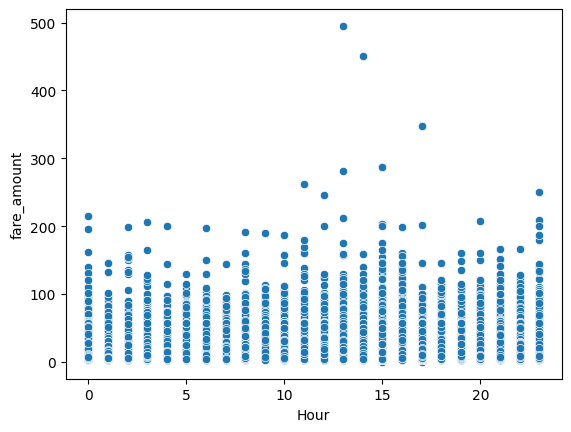

In [30]:
sns.scatterplot(x='Hour', y='fare_amount', data=train_df)


<Axes: xlabel='Distance', ylabel='fare_amount'>

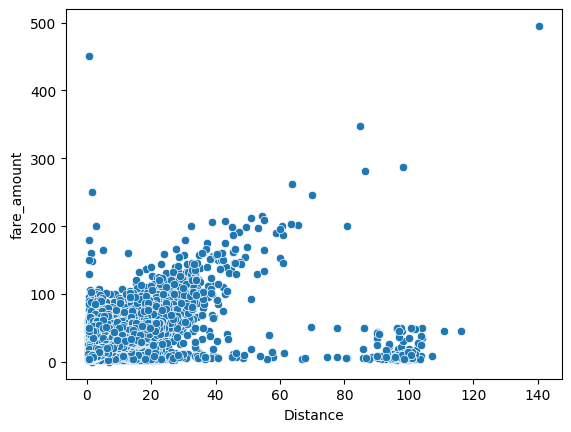

In [31]:
sns.scatterplot(x='Distance', y='fare_amount', data=train_df)


In [32]:
features = train_df.columns[2:]
y = train_df.columns[1]


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor


In [34]:
X_train, X_test, y_train, y_test = train_test_split(train_df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'Year', 'Month', 'Day', 'Weekday', 'Hour', 'Distance']], train_df['fare_amount'], test_size=0.30, random_state=42)


In [35]:
# my_model = XGBRegressor(n_estimators=1000, learning_rate=0.01)
# my_model.fit(X_train, y_train, 
#              early_stopping_rounds=5, 
#              eval_set=[(X_test, y_test)])


In [36]:
# # K Neighbors Regressor
# def KNR(n):
#     knr = KNeighborsRegressor(n_neighbors=n)
#     knr.fit(X_train, y_train)
#     y_pred = knr.predict(X_test)
#     rmse = mean_squared_error(y_test, y_pred, squared=False)
#     return rmse


In [37]:
# for i in range(1,11):
#     print(10*i, ': ', KNR(10*i))


In [38]:
# # Random Forest Regressor
# def RFR(n):
#     rfr = RandomForestRegressor(n_estimators=n, random_state=0)
#     rfr.fit(X_train, y_train)
#     y_pred = rfr.predict(X_test)
#     rmse = mean_squared_error(y_test, y_pred, squared=False)
#     return rmse


In [39]:
# for i in range(1,11):
#     print(10*i, ': ', RFR(10*i))


In [40]:
# # Linear Regression
# def LinReg():
#     linreg = LinearRegression()
#     linreg.fit(X_train, y_train)
#     y_pred = linreg.predict(X_test)
#     rmse = mean_squared_error(y_test, y_pred, squared=False)
#     return rmse


In [41]:
# print(LinReg())


In [42]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.compose import make_column_transformer

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# from tensorflow.keras import callbacks


In [43]:
# preprocessor = make_column_transformer(
#     (StandardScaler(), features),
# )

# X_train = preprocessor.fit_transform(X_train)
# X_test = preprocessor.transform(X_test)
# y_train = y_train/train_df.fare_amount.max()
# y_test = y_test/train_df.fare_amount.max()

# input_shape = [features.shape[0]]


In [44]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


2026-01-07 04:49:52.167675: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767761392.177050      12 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767761392.179874      12 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 04:49:52.192306: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_scalin = scaler.fit_transform(X_train)
val_scalin = scaler.transform(X_test)
test_scalin = scaler.transform(test_df[features])


In [46]:
from keras import backend as K

def root_mean_squared_error(y_true, y_pred):
        return K.sqrt(K.mean(K.square(y_pred - y_true))) 


In [47]:
# define a deep neural network model
def build_and_compile_model(dim):
    model = keras.Sequential([

      layers.Dense(128, activation='relu', input_dim=dim),
      layers.BatchNormalization(),

      layers.Dense(64, activation='relu'),
      layers.BatchNormalization(),

      layers.Dense(32, activation='relu'),
      layers.BatchNormalization(),

      layers.Dense(8, activation='relu'),
      layers.BatchNormalization(),

      layers.Dense(1)
    ])
    
    model.compile(loss=root_mean_squared_error,
                optimizer=tf.keras.optimizers.Adam(0.01), metrics=['mae'])
    return model


In [48]:
dnn_model = build_and_compile_model(dim=features.shape[0])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-07 04:49:58.821782: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767761398.822240      12 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6


In [49]:
ep_no = 10
Batch = 128


In [50]:
%%time
history = dnn_model.fit(
    train_scalin,
    y_train,
    validation_data=(val_scalin, y_test),
    validation_steps=len(val_scalin) // Batch,
    batch_size= Batch,
    epochs=ep_no, verbose=1)


Epoch 1/10


AttributeError: module 'keras.api.backend' has no attribute 'sqrt'

In [51]:
# prediction = my_model.predict(test_df[features])


In [52]:
prediction = dnn_model.predict(test_scalin, batch_size=Batch, verbose=1)


 1/78 ━━━━━━━━━━━━━━━━━━━━ 20s 260ms/step

I0000 00:00:1767761399.883207      67 service.cc:148] XLA service 0x7efb840029a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767761399.883230      67 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-07 04:49:59.888637: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767761399.936942      67 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1767761400.008900      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [53]:
prediction = prediction.ravel()


In [54]:
# X, y = train_df[features], train_df[y]
# knr = KNeighborsRegressor(n_neighbors=50)
# knr.fit(X, y)
# prediction = knr.predict(test_df[features])


In [55]:
# X, y = train_df[features], train_df[y]
# linreg = LinearRegression()
# linreg.fit(X, y)
# prediction = linreg.predict(test_df[features])


In [56]:
# X, y = train_df[features], train_df[y]
# regr = RandomForestRegressor(random_state=0)
# regr.fit(X, y)


In [57]:
# prediction = regr.predict(test_df[features])
# prediction = model.predict(test_df.iloc[:,1:], batch_size=256, verbose=1)


In [58]:
# prediction = prediction.ravel()


In [59]:
submission = pd.DataFrame({
        "key": test_df['key'],
        "fare_amount": prediction
})

submission.to_csv('taxi_fare_submission.csv',index=False)
